In [1]:
import json
from env import CloudClusterEnv, STEPS_PER_WEEK

# load the trace stats the simulator needs

with open('trace_params.json') as f:
    stats = json.load(f)['stats']


Setup complete. Steps per week: 672
CloudClusterEnv defined.


In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.distributions import Normal

# import your environment from notebook 02
# (easiest for now: paste the CloudClusterEnv cell into this notebook too,
#  OR use %run — we'll handle imports cleanly in a moment)

class ActorCritic(nn.Module):
    def __init__(self, state_dim=32, action_dim=1):
        super().__init__()

        # shared body — both actor and critic read the state through this
        self.shared = nn.Sequential(
            nn.Linear(state_dim, 256), nn.Tanh(),
            nn.Linear(256, 256),       nn.Tanh(),
        )

        # actor head: outputs the MEAN of the action distribution
        self.actor_mean = nn.Linear(256, action_dim)

        # a single learnable log-std (not state-dependent) — standard for PPO.
        # controls how much the agent explores around the mean.
        self.log_std = nn.Parameter(torch.zeros(action_dim))

        # critic head: outputs V(s), one number
        self.critic = nn.Linear(256, 1)

    def forward(self, state):
        x = self.shared(state)
        mean = self.actor_mean(x)
        value = self.critic(x)
        return mean, value

    def get_action(self, state):
        """Sample an action (training) and return its log-prob + value."""
        mean, value = self.forward(state)
        std = torch.exp(self.log_std)          # log_std -> std, always positive
        dist = Normal(mean, std)               # Gaussian over the action
        action = dist.sample()                 # sample for exploration
        log_prob = dist.log_prob(action).sum(-1)
        return action, log_prob, value.squeeze(-1)

    def evaluate_actions(self, state, action):
        """Used during the PPO update: re-score stored actions."""
        mean, value = self.forward(state)
        std = torch.exp(self.log_std)
        dist = Normal(mean, std)
        log_prob = dist.log_prob(action).sum(-1)
        entropy = dist.entropy().sum(-1)
        return log_prob, value.squeeze(-1), entropy


# quick shape test
net = ActorCritic()
dummy_state = torch.zeros(1, 32)
action, log_prob, value = net.get_action(dummy_state)
print("action:", action.shape, "log_prob:", log_prob.shape, "value:", value.shape)
print("Network built. Total params:",
      sum(p.numel() for p in net.parameters()))

action: torch.Size([1, 1]) log_prob: torch.Size([1]) value: torch.Size([1])
Network built. Total params: 74755


In [3]:
def compute_gae(rewards, values, dones, next_value, gamma=0.99, lam=0.95):
    """
    Turn a rollout into advantages using Generalised Advantage Estimation.

    rewards    : list of rewards, one per step
    values     : list of critic values V(s), one per step
    dones      : list of done flags (1 if episode ended at this step, else 0)
    next_value : critic's value estimate for the step AFTER the rollout
    gamma      : discount factor (how much future matters)
    lam        : GAE smoothing (bias-variance tradeoff)

    Returns: advantages (list) and returns (list, = advantages + values,
             used as the critic's training target).
    """
    advantages = []
    gae = 0.0
    values = values + [next_value]   # append bootstrap value at the end

    # walk BACKWARDS through the rollout
    for t in reversed(range(len(rewards))):
        # one-step TD error: reward + discounted next value - current value
        # (zeroed out across episode boundaries via (1 - dones[t]))
        delta = rewards[t] + gamma * values[t + 1] * (1 - dones[t]) - values[t]
        # accumulate the smoothed advantage
        gae = delta + gamma * lam * (1 - dones[t]) * gae
        advantages.insert(0, gae)

    # returns = advantage + value  (target for the critic)
    returns = [adv + val for adv, val in zip(advantages, values[:-1])]
    return advantages, returns


# quick test on fake data to confirm it runs and shapes are right
fake_rewards = [1.0, -0.5, 0.2, 1.0]
fake_values  = [0.5, 0.3, 0.4, 0.6]
fake_dones   = [0, 0, 0, 1]           # episode ends on last step
adv, ret = compute_gae(fake_rewards, fake_values, fake_dones, next_value=0.0)
print("advantages:", [round(a, 3) for a in adv])
print("returns:   ", [round(r, 3) for r in ret])

advantages: [1.098, 0.32, 0.77, 0.4]
returns:    [1.598, 0.62, 1.17, 1.0]


In [4]:
def ppo_update(net, optimizer, states, actions, old_log_probs,
               advantages, returns,
               clip_eps=0.2, epochs=4, value_coef=0.5, entropy_coef=0.01):
    """
    Run the PPO update over one rollout.

    net           : the ActorCritic network
    states        : tensor [N, 32]
    actions       : tensor [N, 1]
    old_log_probs : tensor [N]   (log-probs from when actions were taken)
    advantages    : tensor [N]
    returns       : tensor [N]
    """
    # normalise advantages — stabilises training (standard practice)
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    for _ in range(epochs):
        # re-score stored actions under the current policy
        new_log_probs, values, entropy = net.evaluate_actions(states, actions)

        # the PPO ratio: how much has the policy changed for these actions?
        ratio = torch.exp(new_log_probs - old_log_probs)

        # clipped surrogate objective
        unclipped = ratio * advantages
        clipped   = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * advantages
        actor_loss = -torch.min(unclipped, clipped).mean()   # minimise -> maximise reward

        # critic loss: value should predict the return
        critic_loss = ((values - returns) ** 2).mean()

        # entropy bonus: discourage collapsing to a single action
        entropy_loss = entropy.mean()

        # total loss
        loss = actor_loss + value_coef * critic_loss - entropy_coef * entropy_loss

        # gradient step
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), 0.5)   # cap gradient size
        optimizer.step()

    return actor_loss.item(), critic_loss.item(), entropy_loss.item()


# quick test with fake data to confirm it runs
net = ActorCritic()
optimizer = torch.optim.Adam(net.parameters(), lr=3e-4)

N = 10
fake_states = torch.randn(N, 32)
fake_actions = torch.randn(N, 1)
fake_old_lp = torch.randn(N)
fake_adv = torch.randn(N)
fake_ret = torch.randn(N)

a_loss, c_loss, ent = ppo_update(net, optimizer, fake_states, fake_actions,
                                  fake_old_lp, fake_adv, fake_ret)
print(f"actor_loss: {a_loss:.4f}  critic_loss: {c_loss:.4f}  entropy: {ent:.4f}")
print("PPO update ran successfully.")

actor_loss: 0.2529  critic_loss: 0.7949  entropy: 1.4198
PPO update ran successfully.


In [5]:
def train(env, net, optimizer, total_steps=50_000, rollout_len=2048):
    """Train the PPO agent. Collects rollouts and updates repeatedly."""

    state, _ = env.reset()
    state = torch.tensor(state, dtype=torch.float32)

    steps_done = 0
    episode_reward = 0
    episode_rewards = []      # completed-episode returns, for tracking progress
    log = []                  # per-update summary

    while steps_done < total_steps:

        # ---- 1. COLLECT a rollout ----
        states, actions, log_probs = [], [], []
        rewards, values, dones = [], [], []

        for _ in range(rollout_len):
            with torch.no_grad():
                action, log_prob, value = net.get_action(state.unsqueeze(0))

            # step the environment
            a = action.squeeze(0).numpy()
            next_state, reward, done, truncated, info = env.step(a)

            # store
            states.append(state)
            actions.append(action.squeeze(0))
            log_probs.append(log_prob.squeeze(0))
            rewards.append(float(reward))
            values.append(value.item())
            dones.append(1.0 if done else 0.0)

            episode_reward += reward
            state = torch.tensor(next_state, dtype=torch.float32)
            steps_done += 1

            if done:
                episode_rewards.append(episode_reward)
                episode_reward = 0
                state, _ = env.reset()
                state = torch.tensor(state, dtype=torch.float32)

        # ---- 2. BOOTSTRAP value for the step after the rollout ----
        with torch.no_grad():
            _, _, next_value = net.get_action(state.unsqueeze(0))
            next_value = next_value.item()

        # ---- 3. GAE ----
        advantages, returns = compute_gae(rewards, values, dones, next_value)

        # ---- 4. UPDATE ----
        b_states  = torch.stack(states)
        b_actions = torch.stack(actions)
        b_old_lp  = torch.stack(log_probs)
        b_adv     = torch.tensor(advantages, dtype=torch.float32)
        b_ret     = torch.tensor(returns, dtype=torch.float32)

        a_loss, c_loss, ent = ppo_update(net, optimizer, b_states, b_actions,
                                          b_old_lp, b_adv, b_ret)

        # ---- 5. LOG ----
        recent = np.mean(episode_rewards[-5:]) if episode_rewards else float('nan')
        log.append({'steps': steps_done, 'recent_ep_reward': recent,
                    'actor_loss': a_loss, 'critic_loss': c_loss})
        print(f"steps {steps_done:6d} | recent ep reward {recent:10.1f} | "
              f"actor {a_loss:+.3f} critic {c_loss:.3f} entropy {ent:.3f}")

    return episode_rewards, log

In [6]:
# smoke test: short run to confirm learning
env = CloudClusterEnv(stats)
net = ActorCritic()
optimizer = torch.optim.Adam(net.parameters(), lr=3e-4)

print("Starting smoke-test training (250k steps)...\n")
episode_rewards, log = train(env, net, optimizer, total_steps=250_000)

print(f"\nEpisodes completed: {len(episode_rewards)}")
if len(episode_rewards) >= 2:
    print(f"First episode reward: {episode_rewards[0]:.1f}")
    print(f"Last episode reward:  {episode_rewards[-1]:.1f}")

Starting smoke-test training (250k steps)...

steps   2048 | recent ep reward     -171.8 | actor -0.004 critic 17.441 entropy 1.420
steps   4096 | recent ep reward     -168.7 | actor -0.002 critic 16.857 entropy 1.421
steps   6144 | recent ep reward     -156.9 | actor -0.003 critic 12.159 entropy 1.422
steps   8192 | recent ep reward     -143.7 | actor -0.001 critic 13.695 entropy 1.423
steps  10240 | recent ep reward     -151.3 | actor +0.002 critic 20.365 entropy 1.423
steps  12288 | recent ep reward     -157.4 | actor -0.001 critic 21.007 entropy 1.424
steps  14336 | recent ep reward     -156.7 | actor -0.003 critic 18.600 entropy 1.425
steps  16384 | recent ep reward     -144.2 | actor +0.001 critic 10.568 entropy 1.425
steps  18432 | recent ep reward     -144.9 | actor -0.002 critic 12.583 entropy 1.426
steps  20480 | recent ep reward     -151.0 | actor +0.002 critic 7.810 entropy 1.426
steps  22528 | recent ep reward     -158.5 | actor -0.003 critic 8.529 entropy 1.426
steps  245

In [7]:
torch.save(net.state_dict(), 'ppo_smoketest_3.pth')
print("Saved.")

Saved.


In [8]:
def run_rule_based(env, up_threshold=0.70, down_threshold=0.30):
    """
    Rule-based HPA-equivalent baseline. Scales on a fixed CPU threshold,
    exactly like Kubernetes Horizontal Pod Autoscaler. Runs one full
    episode (one week) and returns the metrics.
    """
    obs, _ = env.reset()

    total_reward = 0.0
    total_cost = 0.0
    total_breaches = 0
    total_util = 0.0
    vm_counts = []
    steps = 0

    for t in range(STEPS_PER_WEEK):
        # HPA looks at CURRENT average CPU (the most recent history entry)
        # history[-1] = [avg_cpu, max_cpu, avg_mem, max_mem]
        current_avg_cpu = env.history[-1][0]

        # threshold decision → convert to an action in [-1, 1]
        if current_avg_cpu > up_threshold:
            action = np.array([0.2])      # scale up (small positive)
        elif current_avg_cpu < down_threshold:
            action = np.array([-0.2])     # scale down (small negative)
        else:
            action = np.array([0.0])      # hold

        obs, reward, done, truncated, info = env.step(action)

        total_reward += reward
        total_cost += info['cost']
        total_breaches += info['breaches']
        total_util += info['utilisation']
        vm_counts.append(info['active_vms'])
        steps += 1
        if done:
            break

    return {
        'total_reward': total_reward,
        'total_cost': total_cost,
        'total_breaches': total_breaches,
        'avg_utilisation': total_util / steps,
        'avg_vms': np.mean(vm_counts),
    }


# run the baseline over several episodes and average (workload is random)
print("Running rule-based HPA baseline (5 episodes)...\n")
env = CloudClusterEnv(stats)
results = [run_rule_based(env) for _ in range(5)]

# average the metrics across episodes
baseline = {
    'total_cost':      np.mean([r['total_cost'] for r in results]),
    'total_breaches':  np.mean([r['total_breaches'] for r in results]),
    'avg_utilisation': np.mean([r['avg_utilisation'] for r in results]),
    'avg_vms':         np.mean([r['avg_vms'] for r in results]),
    'total_reward':    np.mean([r['total_reward'] for r in results]),
}

print("RULE-BASED (HPA-equivalent) BASELINE — averaged over 5 weeks:")
print(f"  Total cost:        {baseline['total_cost']:.1f}")
print(f"  Total SLA breaches:{baseline['total_breaches']:.0f}")
print(f"  Avg utilisation:   {baseline['avg_utilisation']:.3f}")
print(f"  Avg VMs used:      {baseline['avg_vms']:.1f}")
print(f"  Total reward:      {baseline['total_reward']:.1f}")

Running rule-based HPA baseline (5 episodes)...

RULE-BASED (HPA-equivalent) BASELINE — averaged over 5 weeks:
  Total cost:        292.2
  Total SLA breaches:1726
  Avg utilisation:   0.560
  Avg VMs used:      8.7
  Total reward:      -82.7


In [9]:
def run_ppo(env, net, n_episodes=5):
    """Run the trained PPO agent (deterministic: use the mean action)
    over several weeks and average the metrics."""
    all_results = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        obs = torch.tensor(obs, dtype=torch.float32)
        total_cost = total_breaches = total_util = 0.0
        vm_counts = []
        steps = 0
        for t in range(STEPS_PER_WEEK):
            with torch.no_grad():
                mean, _ = net.forward(obs.unsqueeze(0))   # MEAN = deterministic
            action = mean.squeeze(0).numpy()
            obs, reward, done, truncated, info = env.step(action)
            obs = torch.tensor(obs, dtype=torch.float32)
            total_cost += info['cost']
            total_breaches += info['breaches']
            total_util += info['utilisation']
            vm_counts.append(info['active_vms'])
            steps += 1
            if done:
                break
        all_results.append({
            'total_cost': total_cost,
            'total_breaches': total_breaches,
            'avg_utilisation': total_util / steps,
            'avg_vms': np.mean(vm_counts),
        })
    return all_results

print("Running trained PPO agent (5 episodes)...\n")
env = CloudClusterEnv(stats)
ppo_results = run_ppo(env, net, n_episodes=5)

ppo = {
    'total_cost':      np.mean([r['total_cost'] for r in ppo_results]),
    'total_breaches':  np.mean([r['total_breaches'] for r in ppo_results]),
    'avg_utilisation': np.mean([r['avg_utilisation'] for r in ppo_results]),
    'avg_vms':         np.mean([r['avg_vms'] for r in ppo_results]),
}

# ---- side by side ----
print("="*52)
print(f"{'METRIC':<22}{'Rule-based':>14}{'PPO':>14}")
print("="*52)
print(f"{'Total cost':<22}{baseline['total_cost']:>14.1f}{ppo['total_cost']:>14.1f}")
print(f"{'SLA breaches':<22}{baseline['total_breaches']:>14.0f}{ppo['total_breaches']:>14.0f}")
print(f"{'Utilisation':<22}{baseline['avg_utilisation']:>14.3f}{ppo['avg_utilisation']:>14.3f}")
print(f"{'Avg VMs':<22}{baseline['avg_vms']:>14.1f}{ppo['avg_vms']:>14.1f}")
print("="*52)

# quick verdict
cost_diff = (ppo['total_cost'] - baseline['total_cost']) / baseline['total_cost'] * 100
breach_diff = (ppo['total_breaches'] - baseline['total_breaches']) / baseline['total_breaches'] * 100
print(f"\nPPO vs rule-based:")
print(f"  cost:     {cost_diff:+.1f}%")
print(f"  breaches: {breach_diff:+.1f}%")

Running trained PPO agent (5 episodes)...

METRIC                    Rule-based           PPO
Total cost                     292.2         182.4
SLA breaches                    1726          1123
Utilisation                    0.560         0.939
Avg VMs                          8.7           5.4

PPO vs rule-based:
  cost:     -37.6%
  breaches: -34.9%


In [10]:
import time

# ── Pareto configurations: from cost-focused to SLA-focused ──────────────
pareto_configs = [
    {'name': 'cost-focused',  'cost': 0.8, 'sla': 0.5, 'util': 0.1},
    {'name': 'balanced-cost', 'cost': 0.5, 'sla': 1.0, 'util': 0.1},
    {'name': 'balanced-sla',  'cost': 0.4, 'sla': 1.5, 'util': 0.1},
    {'name': 'sla-focused',   'cost': 0.3, 'sla': 2.5, 'util': 0.1},
]

pareto_results = []

for cfg in pareto_configs:
    print(f"\n{'='*55}")
    print(f"Training config: {cfg['name']} "
          f"(cost={cfg['cost']}, sla={cfg['sla']})")
    print('='*55)


    # fresh network, train from scratch
    env = CloudClusterEnv(stats, lambda_cost=cfg['cost'], lambda_sla=cfg['sla'], lambda_util=cfg['util'])
    net_cfg = ActorCritic()
    optimizer = torch.optim.Adam(net_cfg.parameters(), lr=3e-4)

    t0 = time.time()
    train(env, net_cfg, optimizer, total_steps=250_000)
    mins = (time.time() - t0) / 60

    # evaluate this config (deterministic, 5 weeks averaged)
    eval_env = CloudClusterEnv(stats, lambda_cost=cfg['cost'], lambda_sla=cfg['sla'], lambda_util=cfg['util'])
    results = run_ppo(eval_env, net_cfg, n_episodes=5)
    avg_cost     = np.mean([r['total_cost'] for r in results])
    avg_breaches = np.mean([r['total_breaches'] for r in results])
    avg_util     = np.mean([r['avg_utilisation'] for r in results])
    avg_vms      = np.mean([r['avg_vms'] for r in results])

    pareto_results.append({
        'name': cfg['name'],
        'lambda_cost': cfg['cost'], 'lambda_sla': cfg['sla'],
        'cost': avg_cost, 'breaches': avg_breaches,
        'utilisation': avg_util, 'avg_vms': avg_vms,
    })

    # save each model
    torch.save(net_cfg.state_dict(), f"ppo_{cfg['name']}.pth")
    print(f"\n  → cost {avg_cost:.1f} | breaches {avg_breaches:.0f} | "
          f"VMs {avg_vms:.1f} | trained in {mins:.1f} min")

print("\n\nALL CONFIGS DONE. Summary:")
print(f"{'config':<16}{'cost':>8}{'breaches':>10}{'avg_vms':>9}")
for r in pareto_results:
    print(f"{r['name']:<16}{r['cost']:>8.1f}{r['breaches']:>10.0f}{r['avg_vms']:>9.1f}")


Training config: cost-focused (cost=0.8, sla=0.5)
steps   2048 | recent ep reward     -294.7 | actor -0.004 critic 49.964 entropy 1.418
steps   4096 | recent ep reward     -282.2 | actor -0.006 critic 40.474 entropy 1.418
steps   6144 | recent ep reward     -261.0 | actor -0.010 critic 32.615 entropy 1.419
steps   8192 | recent ep reward     -256.0 | actor -0.016 critic 33.517 entropy 1.420
steps  10240 | recent ep reward     -220.6 | actor -0.014 critic 17.657 entropy 1.421
steps  12288 | recent ep reward     -179.2 | actor -0.009 critic 10.984 entropy 1.420
steps  14336 | recent ep reward     -136.4 | actor -0.001 critic 5.732 entropy 1.419
steps  16384 | recent ep reward     -112.1 | actor -0.003 critic 5.306 entropy 1.419
steps  18432 | recent ep reward     -103.4 | actor -0.000 critic 5.387 entropy 1.418
steps  20480 | recent ep reward      -99.2 | actor +0.000 critic 5.315 entropy 1.417
steps  22528 | recent ep reward     -100.2 | actor +0.000 critic 5.299 entropy 1.417
steps  2

In [11]:
import json
with open('pareto_results.json', 'w') as f:
    json.dump(pareto_results, f, indent=2)
print("Pareto results saved.")

Pareto results saved.


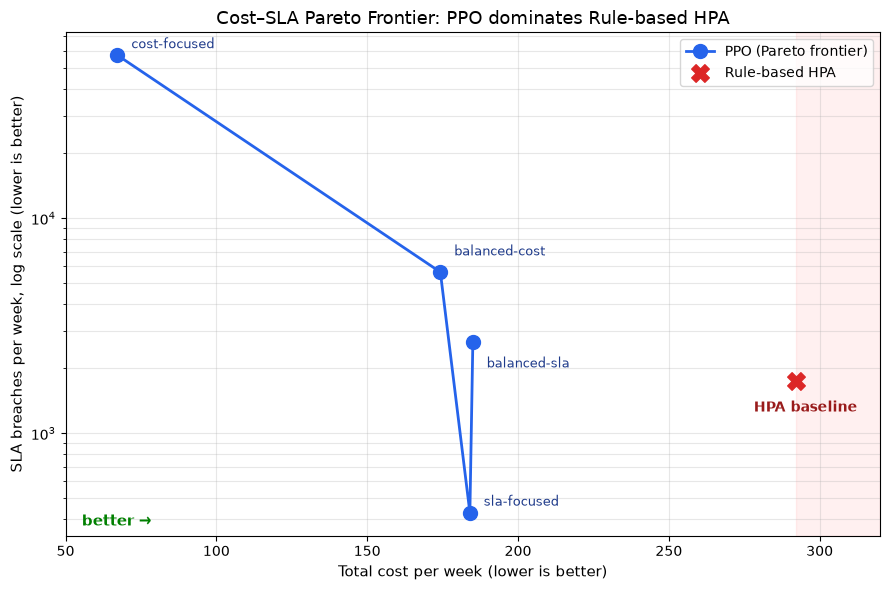

In [12]:
ppo_costs = [r['cost'] for r in pareto_results]
ppo_breaches = [r['breaches'] for r in pareto_results]
ppo_names = [r['name'] for r in pareto_results]


import matplotlib.pyplot as plt

# baseline (use your measured numbers)
baseline_cost, baseline_breaches = 292.0, 1750.0

# PPO points — relabel for clarity, drop the duplicate middle label
pts = sorted(zip(ppo_costs, ppo_breaches, ppo_names))
sc = [p[0] for p in pts]; sb = [p[1] for p in pts]; sn = [p[2] for p in pts]

fig, ax = plt.subplots(figsize=(9, 6))

# shade the region that is WORSE than HPA on both axes (upper-right of PPO)
ax.axvspan(baseline_cost, ax.get_xlim()[1] if False else 320,
           alpha=0.06, color='red')

ax.plot(sc, sb, '-o', color='#2563eb', linewidth=2, markersize=10,
        label='PPO (Pareto frontier)', zorder=3)

# smarter label placement — offset each differently to avoid overlap
offsets = {'cost-focused': (10, 5), 'balanced-cost': (10, 12),
           'balanced-sla': (10, -18), 'sla-focused': (10, 5)}
for c, b, n in zip(sc, sb, sn):
    off = offsets.get(n, (8, 8))
    ax.annotate(n, (c, b), textcoords="offset points", xytext=off,
                fontsize=9, color='#1e3a8a')

ax.scatter([baseline_cost], [baseline_breaches], color='#dc2626',
           s=160, marker='X', label='Rule-based HPA', zorder=4)
ax.annotate('HPA baseline', (baseline_cost, baseline_breaches),
            textcoords="offset points", xytext=(-30, -22),
            fontsize=10, color='#991b1b', fontweight='bold')

ax.set_yscale('log')
ax.set_xlim(50, 320)
ax.set_xlabel('Total cost per week (lower is better)', fontsize=11)
ax.set_ylabel('SLA breaches per week, log scale (lower is better)', fontsize=11)
ax.set_title('Cost–SLA Pareto Frontier: PPO dominates Rule-based HPA', fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3, which='both')
ax.text(0.02, 0.02, 'better →', transform=ax.transAxes,
        fontsize=11, color='green', fontweight='bold')

plt.tight_layout()
plt.savefig('pareto_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
print("FINAL PARETO + BASELINE NUMBERS (for dissertation):")
print(f"  HPA baseline:  cost {baseline_cost:.0f}, breaches {baseline_breaches:.0f}")
for r in pareto_results:
    print(f"  {r['name']:<14}: cost {r['cost']:.0f}, breaches {r['breaches']:.0f}, VMs {r['avg_vms']:.1f}")

FINAL PARETO + BASELINE NUMBERS (for dissertation):
  HPA baseline:  cost 292, breaches 1750
  cost-focused  : cost 67, breaches 57291, VMs 2.0
  balanced-cost : cost 174, breaches 5615, VMs 5.2
  balanced-sla  : cost 185, breaches 2642, VMs 5.5
  sla-focused   : cost 184, breaches 427, VMs 5.5
